In [2]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c

In [3]:
lateU_h0 = 0.73
early_h0 = 0.67
standard_100theta_s = 1.0411
standard_omega_cdm = 0.1201075
standard_omega_b = 0.02238280

In [4]:
quintom_setup = {    
    'Omega_Lambda': 0,
    'Omega_fld' : 0,
    'Omega_qtm': -1,
    'coupled_baryon_qtm' : 'yes',
    'coupled_cdm_qtm' : 'yes',
    'output': 'tCl, mPk'
}

### Dynamics of Quintom Model

In [34]:
quintom_model = Class()
quintom_model.set(quintom_setup)
quintom_model.set({'omega_cdm': standard_omega_cdm,
             'omega_b': standard_omega_b,
             'h': 0.73,
             'lambda_qtm': 0.1,
             'delta_qtm': 0.113})

quintom_model.compute()
bg_quintom = quintom_model.get_background()

quintom_model.struct_cleanup()
quintom_model.empty()

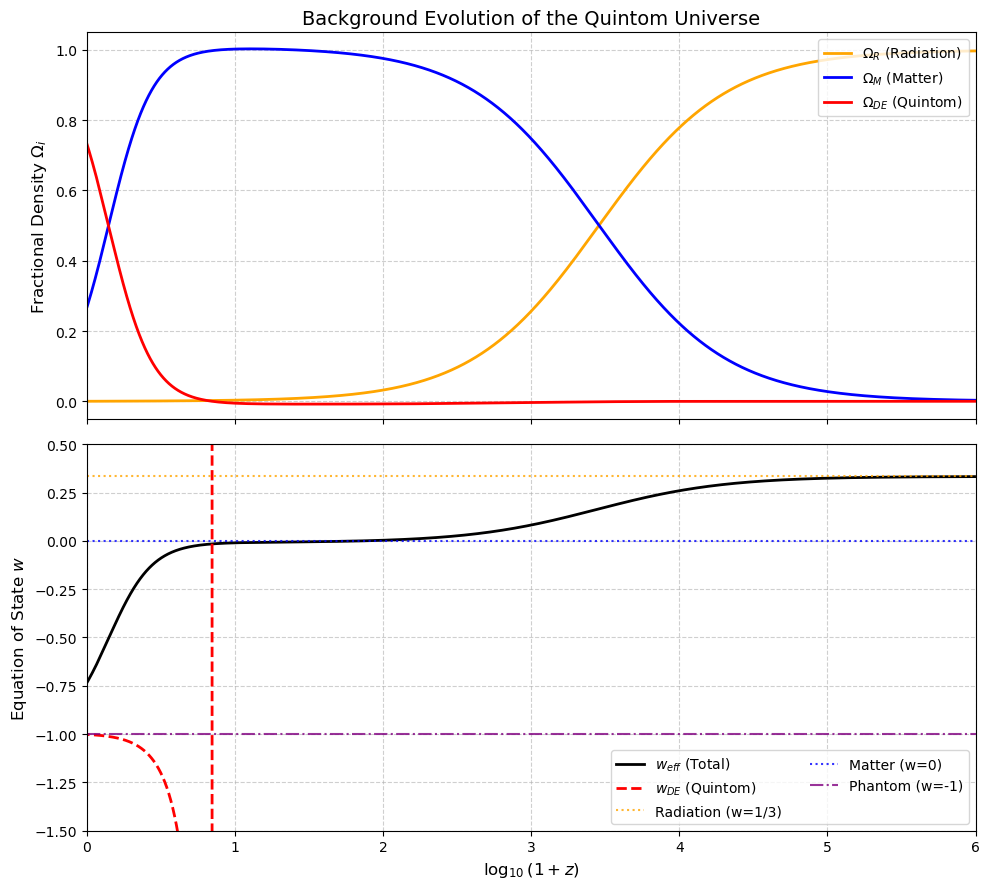

In [33]:
# 1. Define the variables from your CLASS output
log10_one_plus_z = np.log10(1 + bg_quintom['z'])
Omega_M = (bg_quintom['(.)rho_b'] + bg_quintom['(.)rho_cdm']) / bg_quintom['(.)rho_tot']
Omega_DE = bg_quintom['(.)rho_qtm'] / bg_quintom['(.)rho_tot']
Omega_R = (bg_quintom['(.)rho_g'] + bg_quintom['(.)rho_ur']) / bg_quintom['(.)rho_tot']
w_DE = bg_quintom['(.)p_qtm'] / bg_quintom['(.)rho_qtm']
w_eff = bg_quintom['(.)p_tot'] / bg_quintom['(.)rho_tot']

# 2. Set up the figure with two subplots (sharing the x-axis)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

# --- Top Panel: Fractional Densities (Omega) ---
ax1.plot(log10_one_plus_z, Omega_R, label=r'$\Omega_R$ (Radiation)', color='orange', linewidth=2)
ax1.plot(log10_one_plus_z, Omega_M, label=r'$\Omega_M$ (Matter)', color='blue', linewidth=2)
ax1.plot(log10_one_plus_z, Omega_DE, label=r'$\Omega_{DE}$ (Quintom)', color='red', linewidth=2)

ax1.set_ylabel(r'Fractional Density $\Omega_i$', fontsize=12)
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_title('Background Evolution of the Quintom Universe', fontsize=14)

# --- Bottom Panel: Equation of State (w) ---
ax2.plot(log10_one_plus_z, w_eff, label=r'$w_{eff}$ (Total)', color='black', linewidth=2)
ax2.plot(log10_one_plus_z, w_DE, label=r'$w_{DE}$ (Quintom)', color='red', linestyle='--', linewidth=2)

# Add reference lines for standard cosmological epochs
ax2.axhline(1/3, color='orange', linestyle=':', alpha=0.8, label='Radiation (w=1/3)')
ax2.axhline(0, color='blue', linestyle=':', alpha=0.8, label='Matter (w=0)')

# Critical phantom divide line to visualize the Quintom crossing
ax2.axhline(-1, color='purple', linestyle='-.', alpha=0.8, label='Phantom (w=-1)')

ax2.set_ylabel(r'Equation of State $w$', fontsize=12)
ax2.set_ylim(-1.5, 0.5) # Adjust the -1.5 limit based on how deep into the phantom regime your model goes
ax2.legend(loc='lower right', ncol=2)
ax2.grid(True, linestyle='--', alpha=0.6)

# --- Formatting the X-axis ---
ax2.set_xlabel(r'$\log_{10}(1+z)$', fontsize=12)
ax2.set_xlim(0,6)

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

Check if there is phantom crossing

In [32]:
w_DE[-1]

np.float64(-1.002001956662046)

(0.0, 1.0)

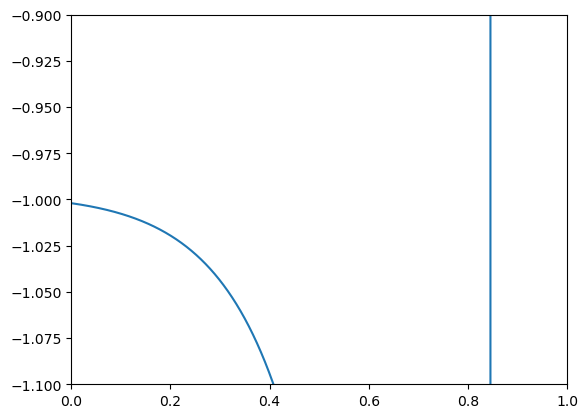

In [30]:
plt.plot(log10_one_plus_z, w_DE)
plt.ylim(-1.1, -0.9)
plt.xlim(0,1)


### The Evolution of Hubble Parameter

Do we need to set h or 100*theta_s ???
if set 100*theta_s, Hubble parameter will be varied
if set h, H0 will be fixed.

In [43]:
quintom_model = Class()
quintom_model.set(quintom_setup)
quintom_model.set({'omega_cdm': standard_omega_cdm,
             'omega_b': standard_omega_b,
             'lambda_qtm': 0.1,
             'delta_qtm': 0.113})

quintom_model.compute()
bg_quintom_1 = quintom_model.get_background()

quintom_model.struct_cleanup()
quintom_model.empty()

In [44]:
Hubble = bg_quintom_1['H [1/Mpc]']*c*10**-3
Hubble[-1]

np.float64(67.80999970372469)

### Parameter Space of $H_0$

#### 1. Space of $\delta$ and $\Omega_M h^2$ 

In [5]:
def omega_m_decomp(omega_m):
    const_ratio = standard_omega_cdm/standard_omega_b
    omega_b = omega_m/(const_ratio+1)
    omega_cdm = omega_m - omega_b
    return [omega_cdm, omega_b]

**Note:** 
- the valid omega_m interval is around (0.14, 0.15). The other values can't compute by CLASS
- the valid delta interval is around (0, 0.10). The other values can't compute by CLASS 

In [8]:
omega_m_list = np.linspace(0.14, 0.15, 10)
lambda_list = np.linspace(0, 0.90, 10)
delta_list = np.linspace(0, 0.10, 10)

In [ ]:
# To check your CPU core count,
import os
print(os.cpu_count())

import multiprocessing as mp
from joblib import Parallel, delayed    # For running parallel
n_core_to_use = 10

12


In [ ]:
def compute_cosmology(omega_m, delta):
    omega_cdm, omega_b = omega_m_decomp(omega_m)
    qtm = Class()
    qtm.set(quintom_setup)
    qtm.set({'100*theta_s': standard_100theta_s, 
             'lambda_qtm': 0.1})
    qtm.set({'omega_cdm': omega_cdm, 'omega_b': omega_b, 'delta_qtm': delta})
    qtm.compute()

    bg_qtm = qtm.get_background()
    res = [
            bg_qtm['H [1/Mpc]'][-1] * c * 10**-3,                        # H_0
            bg_qtm['proper time [Gyr]'][-1]                             # ageU
        ]
    qtm.struct_cleanup()
    qtm.empty()

    return res

# --- Execution ---
paramm_grid  = [(om, d) for om in omega_m_list for d in delta_list]

result_list = Parallel(n_jobs=n_core_to_use)(delayed(compute_cosmology)(om, d) for om, d in paramm_grid)

results = np.array(result_list).reshape(len(omega_m_list), len(delta_list), 2)

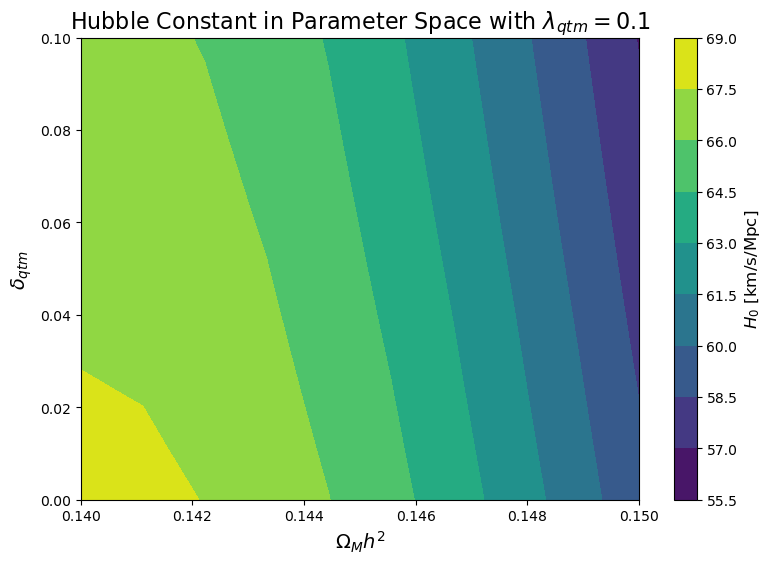

In [57]:
X, Y = np.meshgrid(omega_m_list, delta_list)
Z = results[: , :, 0]

plt.figure(figsize=(9, 6))

# use 'contourf' for filled colors, 'contour' for just lines
cp = plt.contourf(X, Y, Z, levels=10, cmap='viridis')

# Add decorations
cbar = plt.colorbar(cp)
cbar.set_label(r'$H_0$ [km/s/Mpc]', fontsize=12)

plt.xlabel(r'$\Omega_M h^2$', fontsize=14)
plt.ylabel(r'$\delta_{qtm}$', fontsize=14)
plt.title(r'Hubble Constant in Parameter Space with $\lambda_{qtm} = 0.1$', fontsize=16)

plt.show()

#### 2. Space of $\delta$ and $\lambda_\phi$